# 05 — Kalibrasi Probabilitas dan Threshold Review

Fase 5 mengkalibrasi probabilitas kandidat XGBoost yang telah dikunci pada Fase 4, lalu membentuk kebijakan prioritas review manual. Eksperimen tetap kronologis dan hanya menggunakan development set:

- Month 0–4: melatih ulang preprocessing dan spesifikasi model dasar yang sudah dikunci.
- Month 5: mem-fit kandidat kalibrasi sigmoid dan isotonic.
- Month 6: memilih metode kalibrasi, threshold kapasitas, dan risk band.
- Month 7: reserved test; fitur dan label tidak diekspos.

Threshold dan risk band hanya dipakai untuk routing review manual. Tidak ada keputusan penolakan otomatis pada fase ini.

In [1]:
import json
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from fraudshield.calibrate import run_phase5_experiment
from fraudshield.config import load_config
from fraudshield.evaluate import (
    build_error_analysis_frame,
    calibration_table,
)

CONFIG_PATH = Path("../configs/base.yaml")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

## 1. Audit konfigurasi yang dikunci

Model dasar, kandidat calibrator, guardrail seleksi, kapasitas review, dan definisi risk band dibaca sebelum eksperimen dijalankan.

In [2]:
config = load_config(CONFIG_PATH)

calibration_candidates = pd.DataFrame(
    [{"name": "uncalibrated", "method": "identity"}]
    + config["calibration"]["candidates"]
)
selection_policy = pd.Series(
    {
        "base_model": config["calibration"]["base_model_name"],
        "calibrator_fit_periods": config["calibration"]["fit_periods"],
        "selection_periods": config["calibration"]["selection_periods"],
        "primary_metric": config["calibration"]["selection"]["primary_metric"],
        "minimum_brier_improvement": config["calibration"]["selection"]["minimum_absolute_brier_improvement"],
        "maximum_average_precision_drop": config["calibration"]["selection"]["maximum_average_precision_drop"],
        "review_capacity": config["threshold_selection"]["capacity_rate"],
        "threshold_periods": config["threshold_selection"]["selection_periods"],
        "reserved_test_periods": config["split"]["test_periods"],
        "automated_rejection_allowed": config["review_policy"]["automated_rejection_allowed"],
    },
    name="nilai_terkunci",
)
risk_band_config = pd.DataFrame(config["threshold_selection"]["risk_bands"])
xgboost_names = {candidate["name"] for candidate in config["xgboost"]["candidates"]}

assert config["calibration"]["base_model_name"] in xgboost_names
assert config["calibration"]["fit_periods"] == config["split"]["calibration_periods"]
assert config["calibration"]["selection_periods"] == config["split"]["validation_periods"]
assert config["threshold_selection"]["selection_periods"] == config["split"]["validation_periods"]
assert set(config["split"]["test_periods"]).isdisjoint(config["calibration"]["fit_periods"])
assert set(config["split"]["test_periods"]).isdisjoint(config["calibration"]["selection_periods"])
assert config["review_policy"]["automated_rejection_allowed"] is False

display(calibration_candidates)
display(selection_policy.to_frame())
display(risk_band_config)

,name,method,C,max_iter,clip_epsilon,out_of_bounds
0,uncalibrated,identity,NaN,NaN,NaN,NaN
1,sigmoid,sigmoid,1000000.0,1000.0,0.000001,NaN
2,isotonic,isotonic,NaN,NaN,NaN,clip


,nilai_terkunci
base_model,xgboost_strong_regularization
calibrator_fit_periods,[5]
selection_periods,[6]
primary_metric,brier_score
minimum_brier_improvement,0.001
maximum_average_precision_drop,0.005
review_capacity,0.05
threshold_periods,[6]
reserved_test_periods,[7]
automated_rejection_allowed,False


,label,cumulative_review_rate
0,sangat_tinggi,0.01
1,tinggi,0.05
2,menengah,0.10
3,rendah,1.00


## 2. Jalankan eksperimen Fase 5

Cell berikut memvalidasi data, menyiapkan split temporal, melatih ulang spesifikasi XGBoost yang dikunci hanya pada month 0–4, mem-fit calibrator pada month 5, lalu melakukan seluruh keputusan Fase 5 pada month 6. Artifact lokal disimpan ke `artifacts/phase5/`.

In [3]:
result = run_phase5_experiment(
    CONFIG_PATH,
    save_artifacts=True,
)
development_data = result.development_data

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "periods": config["split"]["train_periods"],
            "rows": len(development_data.train_target),
            "prevalence": development_data.train_target.mean(),
            "peran": "fit preprocessing dan model dasar",
        },
        {
            "split": "calibration",
            "periods": config["split"]["calibration_periods"],
            "rows": len(development_data.calibration_target),
            "prevalence": development_data.calibration_target.mean(),
            "peran": "fit sigmoid dan isotonic",
        },
        {
            "split": "validation",
            "periods": config["split"]["validation_periods"],
            "rows": len(development_data.validation_target),
            "prevalence": development_data.validation_target.mean(),
            "peran": "pilih calibrator, threshold, dan risk band",
        },
        {
            "split": "reserved_test",
            "periods": config["split"]["test_periods"],
            "rows": development_data.reserved_test_rows,
            "prevalence": float("nan"),
            "peran": "untouched; fitur dan label tidak diekspos",
        },
    ]
)

display(split_summary)
print("Fitur test tersedia pada objek eksperimen:", hasattr(development_data, "test_features"))
print("Model dasar:", result.base_model_name)
print("Train-only scale_pos_weight:", result.scale_pos_weight)
print("Detik training model dasar:", result.base_training_seconds)
print("Detik fitting calibrator:", result.calibration_seconds)

,split,periods,rows,prevalence,peran
0,train,"[0, 1, 2, 3, 4]",675666,0.009975,fit preprocessing dan model dasar
1,calibration,[5],119323,0.011825,fit sigmoid dan isotonic
2,validation,[6],108168,0.013405,"pilih calibrator, threshold, dan risk band"
3,reserved_test,[7],96843,NaN,untouched; fitur dan label tidak diekspos


Fitur test tersedia pada objek eksperimen: False
Model dasar: xgboost_strong_regularization
Train-only scale_pos_weight: 99.24718100890207
Detik training model dasar: 10.093014900048729
Detik fitting calibrator: {'uncalibrated': 0.0014477999648079276, 'sigmoid': 0.040039699990302324, 'isotonic': 0.017614500015042722}


## 3. Perbandingan metode kalibrasi

Brier score validation adalah metrik utama. Expected calibration error dan log loss menjadi tie-breaker, sedangkan average precision menjadi guardrail agar kualitas ranking tidak turun secara material. Nilai pada calibration month 5 bersifat in-sample untuk calibrator dan tidak digunakan sebagai bukti final.

In [4]:
comparison_columns = [
    "calibration_method",
    "calibration_brier_score_in_sample",
    "calibration_ece_in_sample",
    "validation_brier_score",
    "validation_ece",
    "validation_log_loss",
    "validation_average_precision",
    "validation_roc_auc",
    "calibration_seconds",
    "best_calibrator",
    "selected",
]
display(result.comparison.loc[:, comparison_columns].style.format(precision=6))

,calibration_method,calibration_brier_score_in_sample,calibration_ece_in_sample,validation_brier_score,validation_ece,validation_log_loss,validation_average_precision,validation_roc_auc,calibration_seconds,best_calibrator,selected
0,sigmoid,0.010476,0.000478,0.012023,0.000955,0.053015,0.176706,0.891986,0.040040,True,True
1,isotonic,0.010420,0.000000,0.012050,0.000950,0.054051,0.163800,0.891615,0.017615,False,False
2,uncalibrated,0.104347,0.221494,0.119610,0.239085,0.379825,0.176706,0.891986,0.001448,False,False


## 4. Reliability diagram validation

Setiap panel membandingkan rata-rata probabilitas dengan fraud rate aktual pada bin yang sama. Garis diagonal menunjukkan kalibrasi ideal. Plot ini perlu dibaca bersama jumlah baris per bin dan metrik numerik di atas.

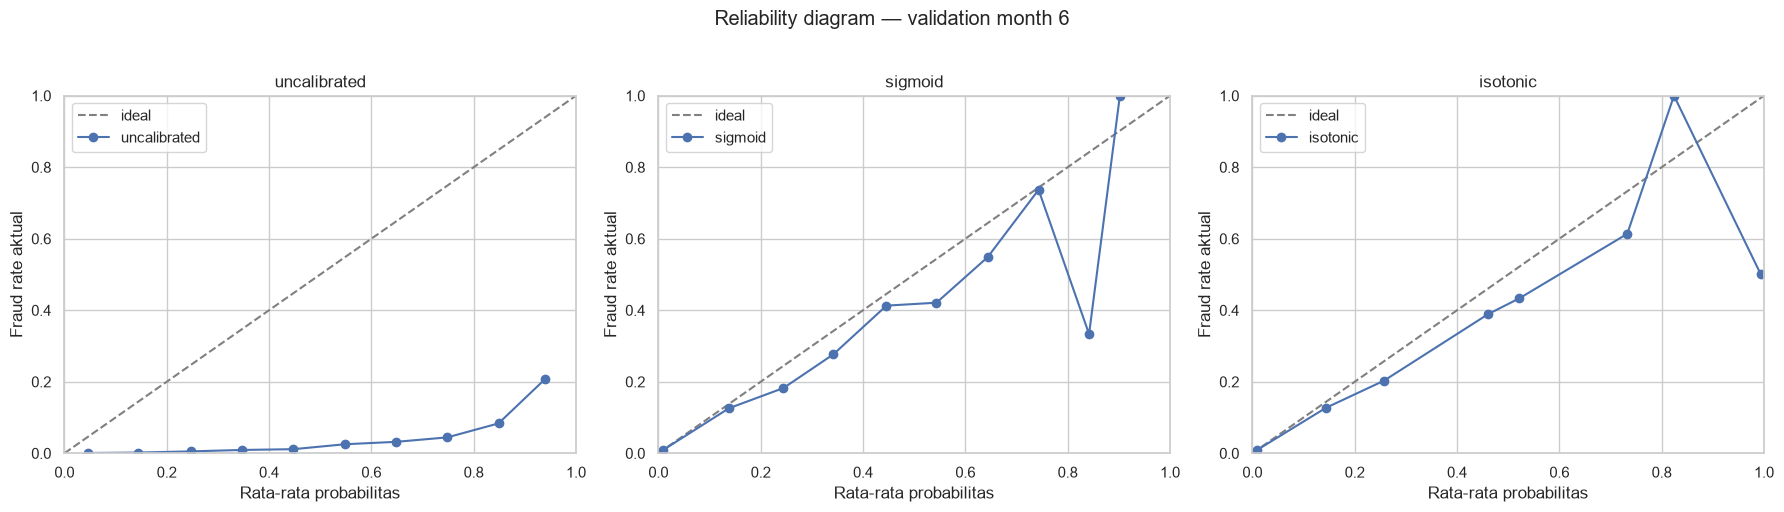

In [5]:
method_names = list(result.probabilities)
figure, axes = plt.subplots(
    1,
    len(method_names),
    figsize=(6 * len(method_names), 5),
    squeeze=False,
)

for axis, method_name in zip(axes[0], method_names, strict=True):
    table = calibration_table(
        development_data.validation_target,
        result.probabilities[method_name]["validation"],
        number_of_bins=config["evaluation"]["calibration_bins"],
    )
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="ideal")
    axis.plot(
        table["mean_predicted_probability"],
        table["observed_fraud_rate"],
        marker="o",
        label=method_name,
    )
    axis.set_title(method_name)
    axis.set_xlabel("Rata-rata probabilitas")
    axis.set_ylabel("Fraud rate aktual")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend()

figure.suptitle("Reliability diagram — validation month 6", y=1.02)
figure.tight_layout()
plt.show()

## 5. Keputusan kalibrasi

Kandidat dengan Brier score terbaik hanya dipromosikan jika memenuhi minimum perbaikan Brier score dan maximum penurunan average precision yang telah dikunci.

In [6]:
decision_record = pd.Series(asdict(result.decision), name="nilai")
display(decision_record.to_frame())

status_keputusan = (
    "dipromosikan"
    if result.decision.calibrator_promoted
    else "probabilitas mentah dipertahankan"
)
display(
    Markdown(
        f"**Keputusan pengembangan:** `{result.decision.selected_calibrator_name}` "
        f"— **{status_keputusan}**.  \
"
        f"{result.decision.reason}"
    )
)

,nilai
baseline_name,uncalibrated
best_calibrator_name,sigmoid
selected_calibrator_name,sigmoid
calibrator_promoted,True
validation_brier_score_baseline,0.11961
validation_brier_score_challenger,0.012023
absolute_brier_improvement,0.107587
minimum_absolute_brier_improvement,0.001
validation_average_precision_baseline,0.176706
validation_average_precision_challenger,0.176706


**Keputusan pengembangan:** `sigmoid` — **dipromosikan**.  Metode kalibrasi terbaik memenuhi guardrail Brier score dan average precision pada validation month 6.

## 6. Threshold kapasitas review

Kapasitas 5% diterjemahkan menjadi score cutoff pada validation. Threshold tie-inclusive ditampilkan untuk audit. Rekomendasi batch menggunakan tie-break deterministik agar jumlah review tepat sesuai kapasitas.

In [7]:
capacity_record = pd.Series(asdict(result.capacity_policy), name="nilai")
selected_method = result.decision.selected_calibrator_name
selected_validation_probability = result.probabilities[selected_method]["validation"]
validation_target = development_data.validation_target.to_numpy()
exact_review_flags = result.calibrated_model.recommend_review(
    development_data.validation_features,
    stable_keys=development_data.validation_features.index.to_numpy(),
)
threshold_flags = result.calibrated_model.at_or_above_threshold(
    development_data.validation_features
)
reviewed_mask = exact_review_flags.astype(bool)
exact_captured_fraud = int(validation_target[reviewed_mask].sum())
exact_capacity_summary = pd.Series(
    {
        "target_review_count": result.capacity_policy.target_review_count,
        "exact_review_count_after_tie_break": int(exact_review_flags.sum()),
        "tie_inclusive_threshold_count": int(threshold_flags.sum()),
        "exact_captured_fraud": exact_captured_fraud,
        "exact_precision_at_capacity": exact_captured_fraud / exact_review_flags.sum(),
        "exact_recall_at_capacity": exact_captured_fraud / validation_target.sum(),
    },
    name="nilai",
)
review_metrics = pd.DataFrame(
    result.threshold_metrics["review_rate_metrics"]
).T.reset_index(names="requested_review_rate_key")

display(capacity_record.to_frame())
display(exact_capacity_summary.to_frame())
display(review_metrics.style.format(precision=6))
assert exact_review_flags.sum() == result.capacity_policy.target_review_count

,nilai
source_split,validation
requested_review_rate,0.05
row_count,108168
target_review_count,5409
score_threshold,0.063432
strictly_above_threshold_count,5408
boundary_tie_count,1
boundary_review_slots,1
observed_at_or_above_threshold_count,5409
observed_at_or_above_threshold_rate,0.050006


,nilai
target_review_count,5409.000000
exact_review_count_after_tie_break,5409.000000
tie_inclusive_threshold_count,5409.000000
exact_captured_fraud,713.000000
exact_precision_at_capacity,0.131817
exact_recall_at_capacity,0.491724


,requested_review_rate_key,requested_review_rate,actual_review_rate,review_count,captured_fraud_count,captured_fraud_count_is_expected,total_fraud_count,precision_at_capacity,recall_at_capacity,fraud_capture_rate,score_cutoff,cutoff_tie_count,cutoff_tie_review_count
0,0.0100,0.010000,0.010003,1082,289.000000,False,1450,0.267098,0.199310,0.199310,0.203000,1,1
1,0.0300,0.030000,0.030009,3246,562.000000,False,1450,0.173136,0.387586,0.387586,0.097169,1,1
2,0.0500,0.050000,0.050006,5409,713.000000,False,1450,0.131817,0.491724,0.491724,0.063432,1,1
3,0.1000,0.100000,0.100002,10817,942.000000,False,1450,0.087085,0.649655,0.649655,0.031115,1,1


## 7. Risk band validation

Risk band menunjukkan segmen relatif terhadap distribusi validation, bukan kepastian fraud. Perhatikan row share, fraud share, dan fraud prevalence pada setiap band.

,risk_band,row_count,row_share,fraud_count,fraud_share,fraud_prevalence,minimum_probability,maximum_probability,mean_probability
0,sangat_tinggi,1082,0.010003,289,0.199310,0.267098,0.203000,0.902040,0.334419
1,tinggi,4327,0.040003,424,0.292414,0.097989,0.063432,0.202945,0.107007
2,menengah,5408,0.049996,229,0.157931,0.042345,0.031115,0.063410,0.044005
3,rendah,97351,0.899998,508,0.350345,0.005218,0.000005,0.031111,0.005036


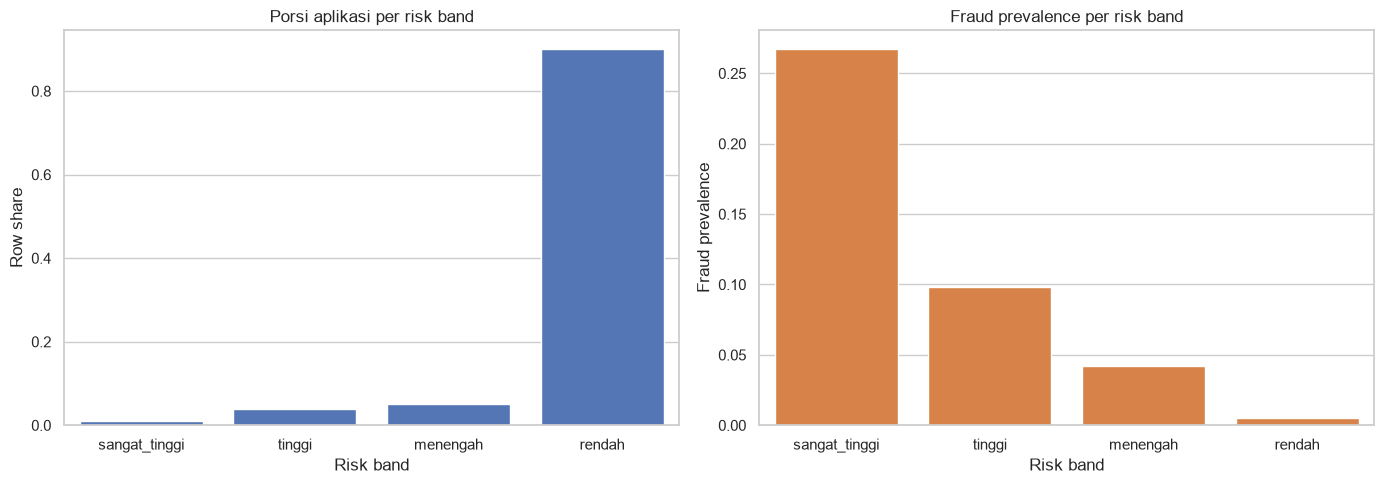

In [8]:
risk_summary = result.risk_band_summary.copy()
display(risk_summary.style.format(precision=6))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=risk_summary, x="risk_band", y="row_share", ax=axes[0], color="#4472C4")
axes[0].set_title("Porsi aplikasi per risk band")
axes[0].set_xlabel("Risk band")
axes[0].set_ylabel("Row share")
sns.barplot(data=risk_summary, x="risk_band", y="fraud_prevalence", ax=axes[1], color="#ED7D31")
axes[1].set_title("Fraud prevalence per risk band")
axes[1].set_xlabel("Risk band")
axes[1].set_ylabel("Fraud prevalence")
figure.tight_layout()
plt.show()

assert risk_summary["row_count"].sum() == len(validation_target)
assert risk_summary["fraud_count"].sum() == validation_target.sum()

## 8. Diagnostic kesalahan pada cutoff review

Confusion matrix berikut bersifat tie-inclusive pada score cutoff yang tersimpan. Contoh kesalahan membantu inspeksi failure mode dan tidak mengubah pemilihan calibrator atau threshold.

In [9]:
selected_errors = build_error_analysis_frame(
    development_data.validation_features,
    development_data.validation_target,
    selected_validation_probability,
    diagnostic_threshold=result.capacity_policy.score_threshold,
    examples_per_error_type=20,
)
diagnostic_columns = [
    "source_index",
    "target",
    "fraud_probability",
    "diagnostic_prediction",
    "error_type",
    "income",
    "customer_age",
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
]
available_diagnostic_columns = [
    column for column in diagnostic_columns if column in selected_errors.columns
]

display(
    pd.Series(
        result.threshold_metrics["diagnostic_confusion_matrix"],
        name="jumlah_baris",
    ).to_frame()
)
display(selected_errors.loc[:, available_diagnostic_columns])

,jumlah_baris
true_negative,102022
false_positive,4696
false_negative,737
true_positive,713


,source_index,target,fraud_probability,diagnostic_prediction,error_type,income,customer_age,payment_type,employment_status,housing_status,source
0,553567,0,0.827077,1,false_positive,0.9,60,AC,CC,BA,INTERNET
1,586799,0,0.812972,1,false_positive,0.9,60,AB,CC,BA,INTERNET
2,575064,0,0.792270,1,false_positive,0.9,60,AC,CC,BA,INTERNET
3,532622,0,0.789232,1,false_positive,0.9,50,AB,CA,BA,INTERNET
4,549102,0,0.761360,1,false_positive,0.9,50,AC,CB,BA,TELEAPP
5,528889,0,0.753042,1,false_positive,0.9,50,AC,CA,BA,INTERNET
6,560332,0,0.705846,1,false_positive,0.9,50,AD,CA,BA,INTERNET
7,573721,0,0.688043,1,false_positive,0.9,50,AB,CA,BA,INTERNET
8,570345,0,0.687206,1,false_positive,0.9,50,AC,CA,BA,INTERNET
9,570807,0,0.678952,1,false_positive,0.9,40,AC,CA,BA,INTERNET


## 9. Audit artifact dan leakage

Assertion berikut gagal tertutup apabila metadata melaporkan akses test, penggunaan periode setelah train untuk mem-fit model dasar, atau izin penolakan otomatis.

In [10]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in result.artifact_paths.items()
    ]
)
metadata_path = result.artifact_paths["metadata"]
phase5_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
guardrails = {
    "test_evaluated": phase5_metadata["test_evaluated"],
    "test_features_exposed": phase5_metadata["test_features_exposed"],
    "base_model_retrained_from_locked_specification": phase5_metadata["base_model_retrained_from_locked_specification"],
    "base_model_refit_with_later_periods": phase5_metadata["base_model_refit_with_later_periods"],
    "preprocessing_fitted_on": phase5_metadata["preprocessing_fitted_on"],
    "calibrator_fitted_on": phase5_metadata["calibrator_fitted_on"],
    "calibrator_selected_on": phase5_metadata["calibrator_selected_on"],
    "threshold_selected_on": phase5_metadata["threshold_selected_on"],
    "selected_calibrator_name": phase5_metadata["selected_calibrator_name"],
    "probability_calibrated": phase5_metadata["probability_calibrated"],
    "business_threshold_selected": phase5_metadata["business_threshold_selected"],
    "threshold_purpose": phase5_metadata["threshold_purpose"],
    "automated_rejection_allowed": phase5_metadata["automated_rejection_allowed"],
}

assert guardrails["test_evaluated"] is False
assert guardrails["test_features_exposed"] is False
assert guardrails["base_model_retrained_from_locked_specification"] is True
assert guardrails["base_model_refit_with_later_periods"] is False
assert guardrails["preprocessing_fitted_on"] == "train_periods_only"
assert guardrails["calibrator_fitted_on"] == "calibration_periods_only"
assert guardrails["calibrator_selected_on"] == "validation_periods_only"
assert guardrails["threshold_selected_on"] == "validation_periods_only"
assert guardrails["business_threshold_selected"] is True
assert guardrails["threshold_purpose"] == "manual_review_prioritization_only"
assert guardrails["automated_rejection_allowed"] is False

display(artifact_table)
display(pd.Series(guardrails, name="nilai").to_frame())

,artifact,path
0,calibrated_model,D:\latihan\fraudshield\artifacts\phase5\calibr...
1,metrics,D:\latihan\fraudshield\artifacts\phase5\calibr...
2,comparison,D:\latihan\fraudshield\artifacts\phase5\calibr...
3,decision,D:\latihan\fraudshield\artifacts\phase5\calibr...
4,capacity_policy,D:\latihan\fraudshield\artifacts\phase5\capaci...
5,risk_band_policy,D:\latihan\fraudshield\artifacts\phase5\risk_b...
6,risk_band_summary,D:\latihan\fraudshield\artifacts\phase5\valida...
7,threshold_metrics,D:\latihan\fraudshield\artifacts\phase5\thresh...
8,calibration_table,D:\latihan\fraudshield\artifacts\phase5\valida...
9,validation_errors,D:\latihan\fraudshield\artifacts\phase5\thresh...


,nilai
test_evaluated,False
test_features_exposed,False
base_model_retrained_from_locked_specification,True
base_model_refit_with_later_periods,False
preprocessing_fitted_on,train_periods_only
calibrator_fitted_on,calibration_periods_only
calibrator_selected_on,validation_periods_only
threshold_selected_on,validation_periods_only
selected_calibrator_name,sigmoid
probability_calibrated,True


## 10. Ringkasan keputusan terhitung

Cell berikut membuat ringkasan dari hasil aktual. Angka tidak ditulis manual agar notebook tetap menjadi satu-satunya sumber bukti eksperimen.

In [11]:
selected_comparison_row = result.comparison.loc[
    result.comparison["calibration_method"].eq(selected_method)
].iloc[0]
raw_comparison_row = result.comparison.loc[
    result.comparison["calibration_method"].eq("uncalibrated")
].iloc[0]

display(
    Markdown(
        f"Metode probabilitas terpilih adalah **`{selected_method}`**. "
        f"Validation Brier score berubah dari "
        f"`{raw_comparison_row['validation_brier_score']:.6f}` menjadi "
        f"`{selected_comparison_row['validation_brier_score']:.6f}`. "
        f"Average precision validation berubah dari "
        f"`{raw_comparison_row['validation_average_precision']:.6f}` menjadi "
        f"`{selected_comparison_row['validation_average_precision']:.6f}`.  \
"
        f"Kebijakan review menggunakan kapasitas "
        f"`{result.capacity_policy.requested_review_rate:.2%}` dengan cutoff "
        f"`{result.capacity_policy.score_threshold:.6f}`. "
        f"Test month 7 tetap tidak dievaluasi."
    )
)

Metode probabilitas terpilih adalah **`sigmoid`**. Validation Brier score berubah dari `0.119610` menjadi `0.012023`. Average precision validation berubah dari `0.176706` menjadi `0.176706`.  Kebijakan review menggunakan kapasitas `5.00%` dengan cutoff `0.063432`. Test month 7 tetap tidak dievaluasi.

## Kesimpulan Fase 5

Berdasarkan aturan seleksi kalibrasi yang telah ditetapkan sebelum eksperimen,
metode `sigmoid` dipilih sebagai calibrator untuk
`xgboost_strong_regularization`.

Pada validation month 6, Brier score membaik dari `0.119610` pada probabilitas
mentah menjadi `0.012023` setelah sigmoid calibration. Perbaikan absolutnya
sebesar `0.107587` atau sekitar `89,95%`. Expected calibration error juga turun
dari `0.239085` menjadi `0.000955`, sedangkan log loss turun dari `0.379825`
menjadi `0.053015`.

Validation average precision tidak berubah setelah sigmoid calibration. Hal ini
menunjukkan bahwa perbaikan kualitas probabilitas tidak mengorbankan kemampuan
ranking model. Kedua guardrail seleksi berhasil dipenuhi:

- Perbaikan Brier score melampaui batas minimum `0.001`.
- Perubahan average precision sebesar `0.0`, sehingga tidak melampaui batas
  penurunan maksimum `0.005`.

Pada kapasitas review 5%, kebijakan memilih 5.409 dari 108.168 aplikasi dengan
score cutoff `0.063432`. Kebijakan tersebut menangkap 713 dari 1.450 aplikasi
fraud, dengan precision `0.131817` dan recall `0.491724`. Tidak terdapat tie
yang memerlukan tie-break tambahan pada batas cutoff.

Risk band menunjukkan pemisahan risiko yang jelas:

- `sangat_tinggi` mencakup top 1% aplikasi dan menangkap 289 fraud.
- `tinggi` mencakup rentang 1–5% dan menangkap 424 fraud.
- `menengah` mencakup rentang 5–10% dan menangkap 229 fraud.
- `rendah` mencakup 90% aplikasi lainnya dan masih mengandung 508 fraud.

Secara kumulatif, top 5% menangkap `49,17%` fraud dan top 10% menangkap sekitar
`64,97%` fraud. Masih adanya fraud pada band rendah menegaskan bahwa risk band
tidak boleh diperlakukan sebagai keputusan menerima atau menolak aplikasi.

Preprocessing dan model dasar hanya di-fit pada month 0–4. Calibrator hanya
di-fit pada month 5, sedangkan metode kalibrasi, threshold, dan risk band dipilih
pada month 6. Month 7 tetap untouched dan tidak digunakan dalam training,
kalibrasi, pemilihan threshold, maupun pelaporan Fase 5.

Model gabungan merupakan kandidat pengembangan untuk prioritas review manual.
Automated rejection tetap dilarang.